# SINR CDF Experiment

This notebook runs the two-mode SINR workflow for the `NTN-TN-BS-SINR` project.

Modes in this notebook:

1. `Mode 1`
   Signal: `BS -> TN`
   Interference: `NTN -> TN`
   SINR is evaluated at the TN receiver.

2. `Mode 2`
   Signal: `TN -> BS sector`
   Interference: `NTN -> BS sector`
   SINR is evaluated at the BS receiver.

Notes:

- NTN nodes are treated only as interferers.
- One shared direct-signal threshold is used to decide whether a pair contributes a SINR sample.
- Each TN user is paired to its strongest valid BS sector before the two modes are evaluated pair by pair.
- Plotting code is intentionally kept in this notebook so titles, styles, and outputs are easy to edit.


In [4]:
from pathlib import Path
                      
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display
from sionna.rt import load_scene

import sinr_cdf_utils as scu
from SceneConfigSionna import SceneConfigSionna


In [5]:
scene_path = Path('/workspace/shizhen/NTN-NULLING-NONCOH/blender_scene_big/10km_times_10km/10km_times_10km.xml')
scene = load_scene(str(scene_path))

SceneConfig = SceneConfigSionna(scene)
SceneConfig.build_coverage_map(grid_size=10, show_xy=True, plot=False)

print(f'Scene loaded from: {scene_path}')


x range: [-5024.417, 5015.583]
y range: [-5047.131, 5042.869]
Scene loaded from: /workspace/shizhen/NTN-NULLING-NONCOH/blender_scene_big/10km_times_10km/10km_times_10km.xml


## Simulation Parameters

These values are the main experiment knobs. Adjust them here before running the experiment cell.


In [6]:
# Deployment
ntn_drop_counts = [0, 100, 200, 300]
tn_rx = 100
bs_row = 3
bs_col = 3
nsect = 3

# Scalar: fixed direction for all macro simulations
# Length-2 tuple: uniformly re-sample per macro simulation
azimuth = (0.0, 360.0)
elevation = (35.0, 89.9)

# Carrier and arrays
# fc = 9.99e9
fc = 7e9
bandwidth_hz = 100e6
bs_tx_rows = 8
bs_tx_cols = 8
tn_rx_rows = 1
tn_rx_cols = 1
bs_tx_antennas = bs_tx_rows * bs_tx_cols

# BS sector orientation
sector_yaw_offset_deg = 0.0
sector_head_down_deg = 5.0
sector_roll_deg = 0.0
sector_yaw_offset_rad = np.deg2rad(sector_yaw_offset_deg)
sector_pitch_rad = -np.deg2rad(sector_head_down_deg)
sector_roll_rad = np.deg2rad(sector_roll_deg)

# Monte Carlo
num_macro_sims = 3
plot_layout_on_first_sim = False
show_progress = True

# Memory control for NTN interference links
ntn_tx_batch_size = 100

# Output names
metrics_output_name = 'two_mode_sinr_metrics.npz'
figure_output_prefix = 'two_mode_sinr_cdf'

print(f'NTN drops: {ntn_drop_counts}')
print('NTN=0 is the no-interference SNR baseline.')
print(f'TN users: {tn_rx}')
print(f'BS grid: {bs_row} x {bs_col}, sectors per BS: {nsect}')
print(f'Satellite azimuth range={azimuth[0]:.1f}-{azimuth[1]:.1f} deg')
print(f'Satellite elevation range={elevation[0]:.1f}-{elevation[1]:.1f} deg')
print(f'NTN TX batch size: {ntn_tx_batch_size}')
print(
    f'BS sector orientation: yaw_offset={sector_yaw_offset_deg:.1f} deg, '
    f'head_down={sector_head_down_deg:.1f} deg, roll={sector_roll_deg:.1f} deg'
)


NTN drops: [0, 100, 200, 300]
NTN=0 is the no-interference SNR baseline.
TN users: 100
BS grid: 3 x 3, sectors per BS: 3
Satellite azimuth range=0.0-360.0 deg
Satellite elevation range=35.0-89.9 deg
NTN TX batch size: 100
BS sector orientation: yaw_offset=0.0 deg, head_down=5.0 deg, roll=0.0 deg


In [7]:
# Powers and receiver noise
thermal_noise_density_dbm_hz = -174
bs_tx_power_dbm = 40
tn_tx_power_dbm = 23
ntn_tx_power_dbm = 25

bs_tx_power = 10 ** ((bs_tx_power_dbm - 30) / 10)
tn_tx_power = 10 ** ((tn_tx_power_dbm - 30) / 10)
ntn_tx_power = 10 ** ((ntn_tx_power_dbm - 30) / 10)

tn_nf_db = 7
bs_nf_db = 5

tn_noise_power_dbm = thermal_noise_density_dbm_hz + 10 * np.log10(bandwidth_hz) + tn_nf_db
bs_noise_power_dbm = thermal_noise_density_dbm_hz + 10 * np.log10(bandwidth_hz) + bs_nf_db

tn_noise_power = 10 ** ((tn_noise_power_dbm - 30) / 10)
bs_noise_power = 10 ** ((bs_noise_power_dbm - 30) / 10)

# One shared direct-signal threshold used in both modes.
signal_threshold_db = -6
signal_channel_threshold = np.sqrt(
    10 ** (signal_threshold_db / 10) * bs_noise_power * bs_tx_antennas / bs_tx_power
)

print(f'BS TX power: {bs_tx_power_dbm:.1f} dBm')
print(f'TN TX power: {tn_tx_power_dbm:.1f} dBm')
print(f'NTN TX power: {ntn_tx_power_dbm:.1f} dBm')
print(f'TN noise power: {tn_noise_power_dbm:.2f} dBm')
print(f'BS noise power: {bs_noise_power_dbm:.2f} dBm')
print(f'Shared signal threshold: {signal_threshold_db:.1f} dB')
print(f'Shared channel threshold: {signal_channel_threshold:.4e}')


BS TX power: 40.0 dBm
TN TX power: 23.0 dBm
NTN TX power: 25.0 dBm
TN noise power: -87.00 dBm
BS noise power: -89.00 dBm
Shared signal threshold: -6.0 dB
Shared channel threshold: 1.4226e-06


## Run Experiment

This cell runs the two-mode SINR experiment and saves the raw metrics. Plotting is handled in the notebook cells below.


In [8]:
result_dir = Path('result')
result_dir.mkdir(parents=True, exist_ok=True)

compute_positions_kwargs = dict(
    # `ntn_rx` is swept internally by `ntn_drop_counts`.
    tn_rx=tn_rx,
    azimuth=azimuth,
    elevation=elevation,
    centerBS=False,
    bs_grid=(bs_row, bs_col),
    bs_boundary=1500,
    # tn_building_ratio='sector',
    tn_building_ratio=0.6,
    tn_distance=400,
    ntn_building_ratio=0.6,
    plot_grid=plot_layout_on_first_sim,
    plot_bs=plot_layout_on_first_sim,
    plot_tn=plot_layout_on_first_sim,
    plot_ntn=plot_layout_on_first_sim,
)

compute_cir_kwargs = dict(
    nsect=nsect,
    fc=fc,
    tx_rows=bs_tx_rows,
    tx_cols=bs_tx_cols,
    tn_rx_rows=tn_rx_rows,
    tn_rx_cols=tn_rx_cols,
    max_depth=0,
    bandwidth=bandwidth_hz,
    tx_power_dbm=bs_tx_power_dbm,
    tn_tx_power_dbm=tn_tx_power_dbm,
    ntn_tx_power_dbm=ntn_tx_power_dbm,
    ntn_tx_batch_size=ntn_tx_batch_size,
    sector_yaw_offset_rad=sector_yaw_offset_rad,
    sector_pitch_rad=sector_pitch_rad,
    sector_roll_rad=sector_roll_rad,
)

sinr_results = scu.run_two_mode_sinr_cdf_experiment(
    SceneConfig,
    num_macro_sims=num_macro_sims,
    ntn_drop_counts=ntn_drop_counts,
    compute_positions_kwargs=compute_positions_kwargs,
    compute_cir_kwargs=compute_cir_kwargs,
    h_tn_th=signal_channel_threshold,
    bs_tx_power=bs_tx_power,
    tn_tx_power=tn_tx_power,
    ntn_tx_power=ntn_tx_power,
    tn_noise_power=tn_noise_power,
    bs_noise_power=bs_noise_power,
    plot_first_sim_only=plot_layout_on_first_sim,
    show_progress=show_progress,
)

metrics_path = scu.save_two_mode_sinr_metrics(
    sinr_results,
    result_dir=result_dir,
    output_name=metrics_output_name,
)
sinr_results['metrics_path'] = metrics_path

print(f"Metrics saved to: {metrics_path}")


NTN=0:   0%|          | 0/3 [00:00<?, ?it/s]

NTN=100:   0%|          | 0/3 [00:00<?, ?it/s]

NTN=200:   0%|          | 0/3 [00:00<?, ?it/s]

NTN=300:   0%|          | 0/3 [00:00<?, ?it/s]

Metrics saved to: result/two_mode_sinr_metrics.npz


In [9]:
print('Per-NTN summary')
print(f"{'NTN':>5} {'Mode1N':>8} {'Mode2N':>8} {'AvgPairs':>10} {'AvgTXused':>10} {'AvgEmptyTX':>11}")
print('-' * 60)

for ntn_count in map(int, sinr_results['ntn_drop_counts']):
    mode1_vals = np.asarray(sinr_results['mode1_sinr_db'][ntn_count], dtype=np.float64)
    mode2_vals = np.asarray(sinr_results['mode2_sinr_db'][ntn_count], dtype=np.float64)
    rows = sinr_results['macro_stats'][ntn_count]
    paired = np.asarray([row['paired_tn_count'] for row in rows], dtype=np.float64)
    used = np.asarray([row['num_tx_with_pairs'] for row in rows], dtype=np.float64)
    empty = np.asarray([row['empty_tx_count'] for row in rows], dtype=np.float64)
    print(
        f"{ntn_count:5d} "
        f"{mode1_vals.size:8d} "
        f"{mode2_vals.size:8d} "
        f"{paired.mean() if paired.size else 0:10.2f} "
        f"{used.mean() if used.size else 0:10.2f} "
        f"{empty.mean() if empty.size else 0:11.2f}"
    )


Per-NTN summary
  NTN   Mode1N   Mode2N   AvgPairs  AvgTXused  AvgEmptyTX
------------------------------------------------------------
    0      279      279      93.00      25.33        1.67
  100      272      272      90.67      26.00        1.00
  200      281      281      93.67      25.00        2.00
  300      276      276      92.00      26.00        1.00


## Plot Results

The full CDF plotting code lives here in the notebook so you can edit colors, styles, titles, and save names directly.

`NTN=0` is plotted as an SNR baseline because there is no NTN interference in that case.


In [10]:
def cdf_curve(values):
    vals = np.asarray(values, dtype=np.float64)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return np.empty((0,), dtype=np.float64), np.empty((0,), dtype=np.float64)
    vals_sorted = np.sort(vals)
    cdf = np.arange(1, vals_sorted.size + 1, dtype=np.float64) / float(vals_sorted.size)
    return vals_sorted, cdf


plt.rcParams.update(
    {
        'font.family': 'serif',
        'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
        'font.size': 8,
        'axes.labelsize': 8,
        'axes.titlesize': 8,
        'legend.fontsize': 7,
        'xtick.labelsize': 7,
        'ytick.labelsize': 7,
        'lines.linewidth': 1.4,
    }
)

colors = ['#000000', '#1f77b4', '#d62728', '#2ca02c', '#ff7f0e', '#8c564b', '#17becf']
styles = ['-', '--', '-.', ':', (0, (4, 1, 1, 1)), (0, (6, 2))]
figure_size = (3.5, 2.6)

mode_specs = [
    (
        'mode1_sinr_db',
        'mode1',
        'TN SINR CDF',
        'Signal: BS, Interference: NTN',
    ),
    (
        'mode2_sinr_db',
        'mode2',
        'BS SINR CDF',
        'Signal: TN, Interference: NTN',
    ),
]

figure_paths = {}
for key, tag, title, subtitle in mode_specs:
    fig, ax = plt.subplots(figsize=figure_size)
    data = sinr_results.get(key, {})
    plotted = False

    for idx, ntn_count in enumerate(sorted(int(v) for v in data.keys())):
        x, y = cdf_curve(data[int(ntn_count)])
        if x.size == 0:
            continue
        label = 'NTN=0 (SNR)' if int(ntn_count) == 0 else f'NTN={int(ntn_count)}'
        ax.plot(
            x,
            y,
            color=colors[idx % len(colors)],
            linestyle=styles[idx % len(styles)],
            label=label,
        )
        plotted = True

    ax.set_xlabel('SINR / SNR (dB)')
    ax.set_ylabel('CDF')
    ax.set_title(f'{title}\n{subtitle}')
    ax.set_ylim(0.0, 1.0)
    ax.grid(True, linestyle=':', linewidth=0.6, alpha=0.8)
    if plotted:
        ax.legend(loc='upper left', frameon=True)
    fig.tight_layout(pad=0.2)

    png_path = result_dir / f'{figure_output_prefix}_{tag}.png'
    pdf_path = result_dir / f'{figure_output_prefix}_{tag}.pdf'
    fig.savefig(png_path, dpi=400, bbox_inches='tight')
    fig.savefig(pdf_path, bbox_inches='tight')
    plt.close(fig)

    figure_paths[tag] = {'png': png_path, 'pdf': pdf_path}
    print(f'{tag}: {png_path}')
    print(f'{tag}: {pdf_path}')

sinr_results['figure_paths'] = figure_paths


mode1: result/two_mode_sinr_cdf_mode1.png
mode1: result/two_mode_sinr_cdf_mode1.pdf
mode2: result/two_mode_sinr_cdf_mode2.png
mode2: result/two_mode_sinr_cdf_mode2.pdf


Displaying mode1 CDF


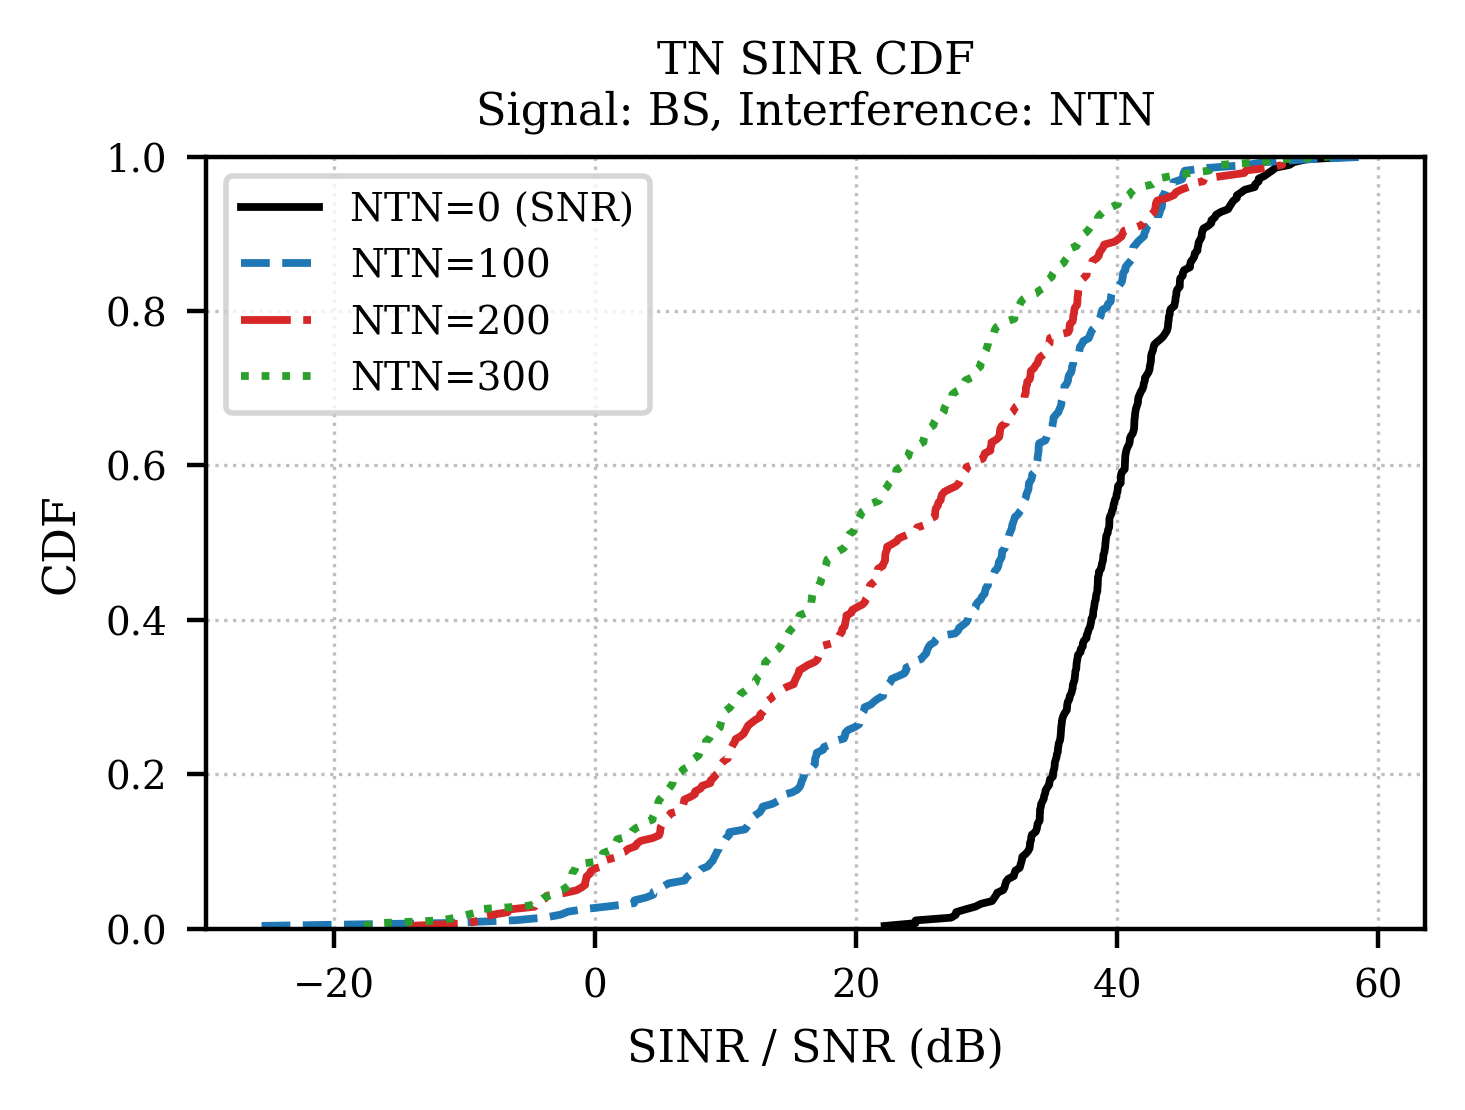

Displaying mode2 CDF


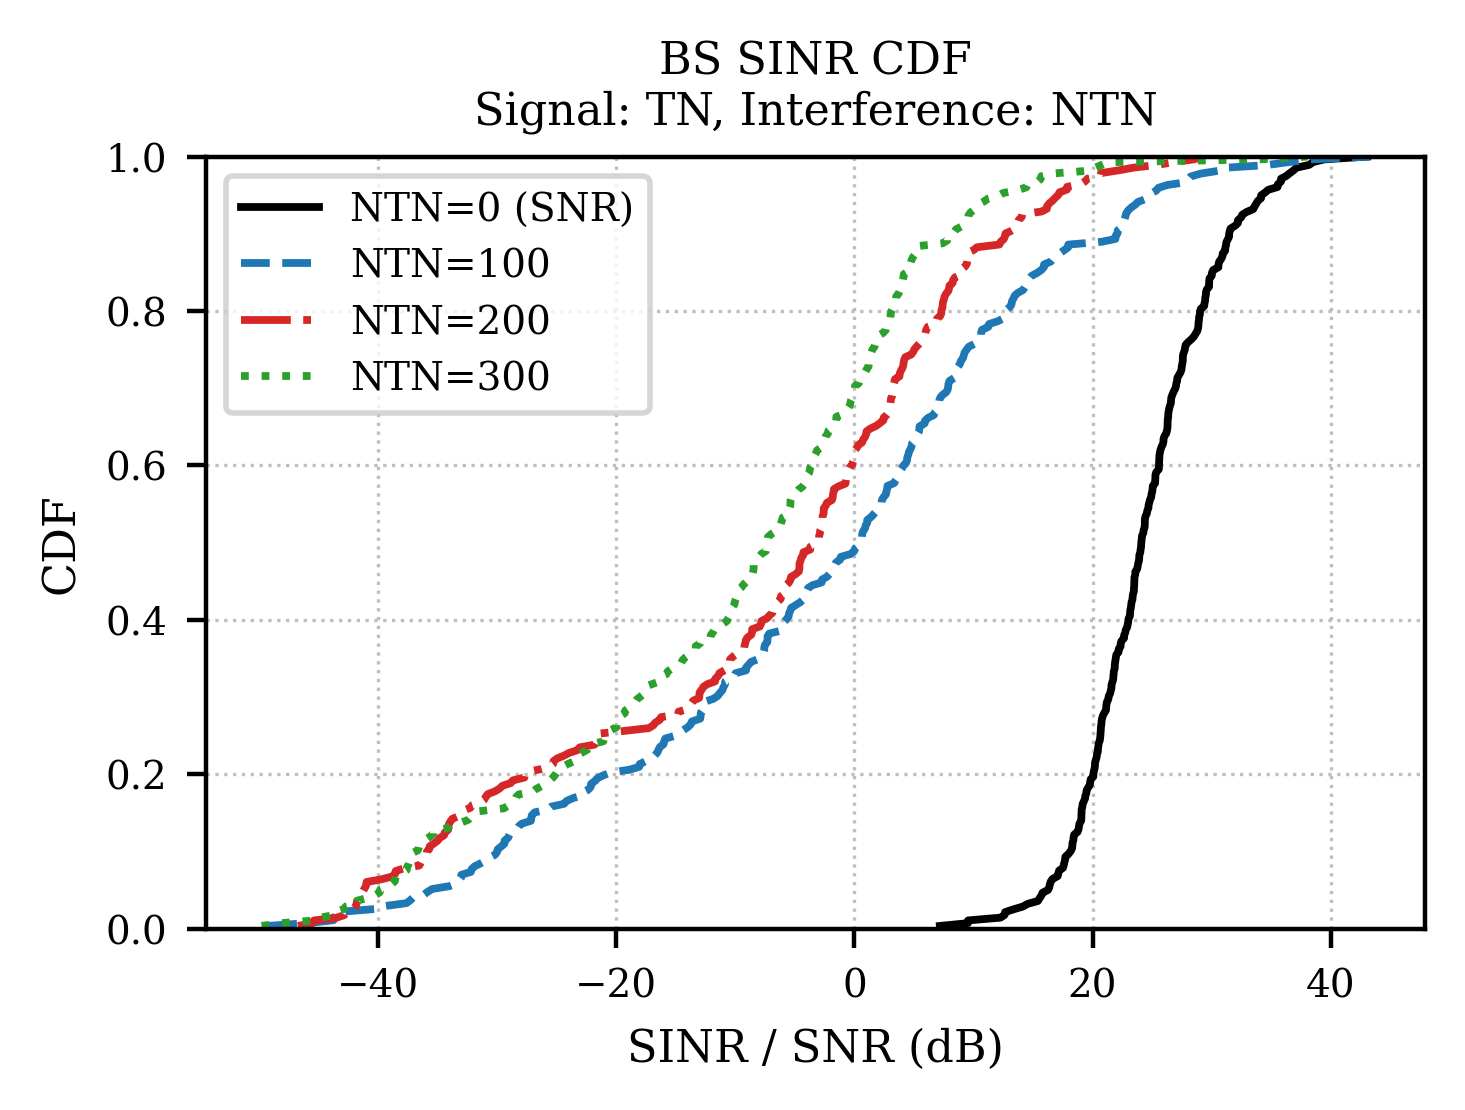

In [11]:
for mode_name in ('mode1', 'mode2'):
    print(f'Displaying {mode_name} CDF')
    display(Image(filename=str(sinr_results['figure_paths'][mode_name]['png'])))
